# Method selection: Discounted Future-Fate Propagation

This notebook explains, visually and mathematically, why scCS uses
**Discounted Future-Fate Propagation (DFFP)** for future identity.

DFFP is not a transformation of UMAP arrows into the star. It propagates
probability on the original RNA-velocity transition graph with geometric
stopping. The star remains a standardized display.

The notebook introduces the public terminology:

- **Conditional Fate Affinity (CFA)** — relative identity among selected fates;
- **Discounted Fate Reach (DFR)** — probability of reaching a selected fate;
- **Future-Fate Specificity (FFS)** — decisiveness among selected fates;
- **Resolved Commitment (RC)** — DFR × FFS;
- **Unresolved Future Probability (UFP)** — probability not assigned before stopping;
- **Signed Ordering Flux (SOF)** — forward or retrograde expected ordering change.

## 1. Imports and reproducibility

The examples are synthetic so that every assumption is visible. They use the
same public solver called by `scoring_mode="future_fate"`.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

import scCS

SEED = 20260714
rng = np.random.default_rng(SEED)
plt.rcParams["figure.dpi"] = 110

print("scCS", scCS.__version__)

scCS 0.8.0.dev34


## 2. Mathematical definition of DFFP

Let $P$ be the row-stochastic RNA-velocity transition matrix and let $A$ identify selected and optional competing outcome anchors. Anchor states are made absorbing. For an effective horizon $h$,

$$
\gamma=\frac{h}{h+1}, \qquad \mathbb{E}[\text{continued transitions}]=\frac{\gamma}{1-\gamma}=h.
$$

The discounted outcome matrix $H$ satisfies

$$
H_i=A_i \text{ on anchors}, \qquad H_i=\gamma\sum_jP^*_{ij}H_j \text{ otherwise}.
$$

For transient block $Q$ and transient-to-anchor block $R$,

$$
(I-\gamma Q)H_T=\gamma R.
$$

Unresolved Future Probability is $U_i=1-\sum_oH_{io}$. This is why DFFP can allow leave-and-return paths without assigning every sufficiently long random walk to a fate.

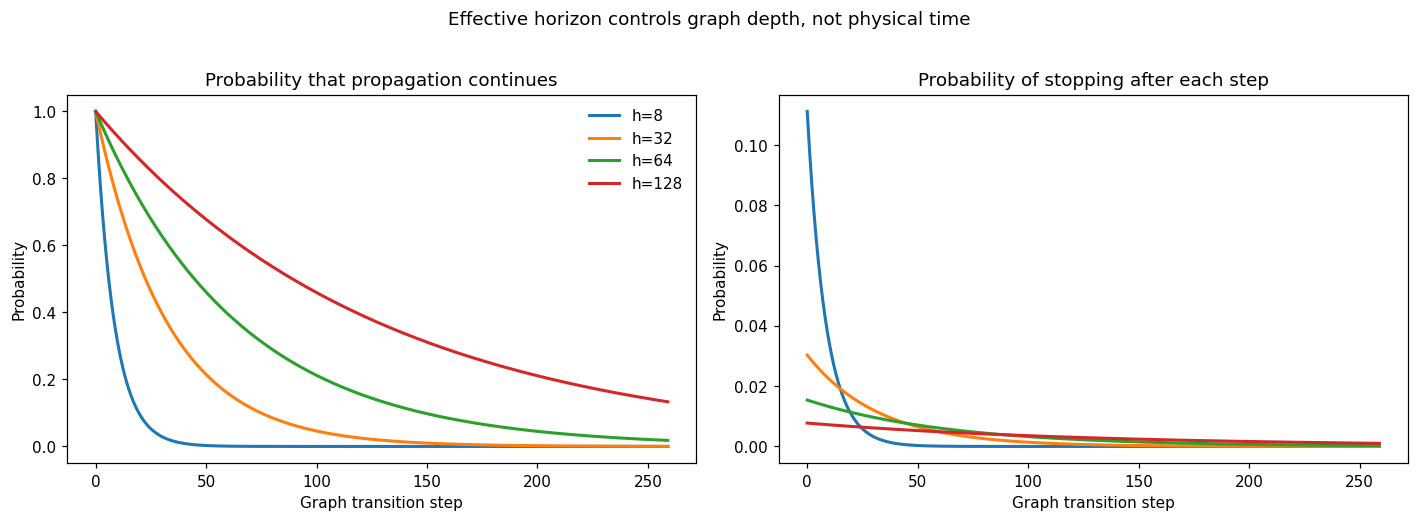

In [2]:
horizons_for_stopping = [8, 32, 64, 128]
steps = np.arange(0, 260)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for horizon in horizons_for_stopping:
    gamma = horizon / (horizon + 1.0)
    survival = gamma ** steps
    stop_probability = (1.0 - gamma) * gamma ** steps
    axes[0].plot(steps, survival, linewidth=2, label=f"h={horizon}")
    axes[1].plot(steps, stop_probability, linewidth=2, label=f"h={horizon}")
axes[0].set_title("Probability that propagation continues")
axes[1].set_title("Probability of stopping after each step")
for axis in axes:
    axis.set_xlabel("Graph transition step")
    axis.set_ylabel("Probability")
axes[0].legend(frameon=False)
fig.suptitle("Effective horizon controls graph depth, not physical time", y=1.02)
fig.tight_layout()
plt.show()

## 3. From outcome probability to scCS metrics

For selected-fate probabilities $p_{if}$:

$$
\mathrm{DFR}_i=R_i=\sum_fp_{if}, \qquad
\mathrm{CFA}_{if}=q_{if}=\frac{p_{if}}{R_i}.
$$

$$
E_i=-\frac{\sum_fq_{if}\log q_{if}}{\log K}, \qquad
\mathrm{FFS}_i=1-E_i, \qquad
\mathrm{RC}_i=R_i\mathrm{FFS}_i.
$$

CFA describes *which future*, DFR describes *how much future is resolved*, FFS describes *how decisive the distribution is*, and RC combines resolution with decisiveness. They should not be collapsed into one unlabeled score.

## 4. A leave-and-return source graph

The selected furcation contains a root, an intermediate state, and two fate
anchors. One valid path temporarily leaves the selected cells and returns before
reaching fate A.

A first-exit model calls the excursion irreversible escape. DFFP keeps the
outside state in the original graph and therefore preserves the return.

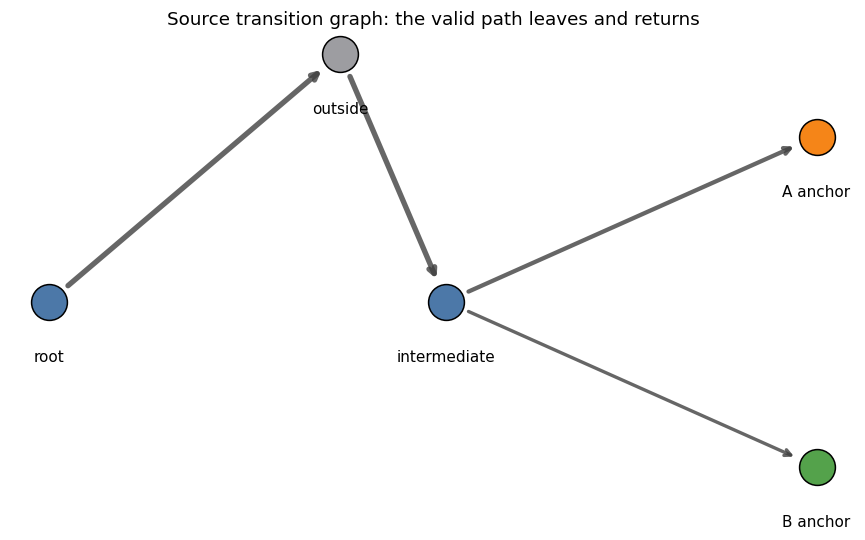

In [3]:
state_names = ["root", "intermediate", "A anchor", "outside", "B anchor"]
transition = sparse.csr_matrix(
    np.array(
        [
            [0.00, 0.00, 0.00, 1.00, 0.00],
            [0.00, 0.00, 0.65, 0.00, 0.35],
            [0.00, 0.00, 1.00, 0.00, 0.00],
            [0.00, 1.00, 0.00, 0.00, 0.00],
            [0.00, 0.00, 0.00, 0.00, 1.00],
        ],
        dtype=float,
    )
)
anchors = np.zeros((5, 2), dtype=bool)
anchors[2, 0] = True
anchors[4, 1] = True

positions = {
    0: (-1.5, 0.0),
    1: (0.0, 0.0),
    2: (1.4, 0.8),
    3: (-0.4, 1.2),
    4: (1.4, -0.8),
}
node_groups = ["selected", "selected", "fate A", "outside", "fate B"]
group_colors = {
    "selected": "#4c78a8",
    "outside": "#9d9da1",
    "fate A": "#f58518",
    "fate B": "#54a24b",
}

fig, ax = plt.subplots(figsize=(8, 5))
for source in range(transition.shape[0]):
    start, stop = transition.indptr[source : source + 2]
    for target, weight in zip(
        transition.indices[start:stop],
        transition.data[start:stop],
    ):
        if source == target or weight == 0:
            continue
        x0, y0 = positions[source]
        x1, y1 = positions[int(target)]
        ax.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.5 + 2.0 * float(weight),
                "alpha": 0.8,
                "color": "0.25",
                "shrinkA": 16,
                "shrinkB": 16,
            },
        )
for index, name in enumerate(state_names):
    x, y = positions[index]
    ax.scatter(
        x,
        y,
        s=550,
        color=group_colors[node_groups[index]],
        edgecolor="black",
        zorder=3,
    )
    ax.text(x, y - 0.23, name, ha="center", va="top")
ax.set_title("Source transition graph: the valid path leaves and returns")
ax.set_axis_off()
fig.tight_layout()
plt.show()

## 5. DFFP across effective horizons

For effective horizon \(h\), the geometric continuation probability is

\[
\gamma = \frac{h}{h+1}.
\]

DFFP solves the discounted hitting probabilities for all supplied anchors.
Unresolved probability remains explicit instead of being forced into a fate.

,effective_horizon,P(A),P(B),DFR,UFP
0,2,0.192593,0.103704,0.296296,0.703704
1,4,0.332800,0.179200,0.512000,0.488000
2,8,0.456516,0.245816,0.702332,0.297668
3,16,0.541909,0.291797,0.833706,0.166294
4,32,0.592682,0.319136,0.911818,0.088182
5,64,0.620459,0.334093,0.954553,0.045447
6,128,0.635001,0.341923,0.976924,0.023076


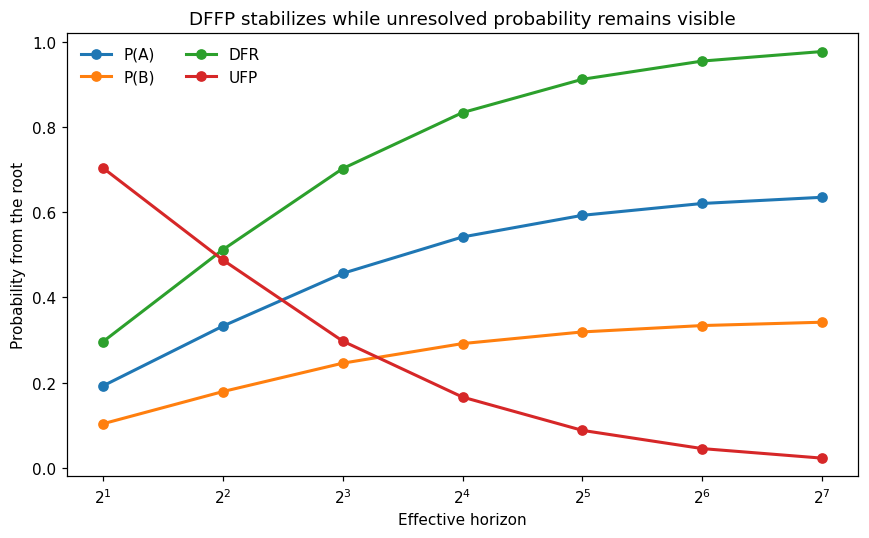

In [4]:
horizons = [2, 4, 8, 16, 32, 64, 128]
records = []
solutions = {}
for horizon in horizons:
    solution = scCS.solve_discounted_outcomes(
        transition,
        anchors,
        ("A", "B"),
        effective_horizon=horizon,
    )
    solutions[horizon] = solution
    records.append(
        {
            "effective_horizon": horizon,
            "P(A)": solution.probability[0, 0],
            "P(B)": solution.probability[0, 1],
            "DFR": solution.probability[0].sum(),
            "UFP": solution.unresolved_probability[0],
        }
    )

horizon_table = pd.DataFrame(records)
display(horizon_table)

fig, ax = plt.subplots(figsize=(8, 5))
for column in ["P(A)", "P(B)", "DFR", "UFP"]:
    ax.plot(
        horizon_table["effective_horizon"],
        horizon_table[column],
        marker="o",
        linewidth=2,
        label=column,
    )
ax.set_xscale("log", base=2)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Effective horizon")
ax.set_ylabel("Probability from the root")
ax.set_title("DFFP stabilizes while unresolved probability remains visible")
ax.legend(frameon=False, ncols=2)
fig.tight_layout()
plt.show()

## 6. First exit, unlimited mixing, and DFFP estimate different quantities

- **First exit** measures whether a path stays inside the selected cell set.
- **Unlimited absorption** eventually assigns almost every state in a connected
  graph to an anchor, even after long graph mixing.
- **DFFP** allows leave-and-return paths but discounts remote futures.

These are not interchangeable tuning options.

,P(A),P(B),escape_or_unresolved
method,,,
First exit,0.000000,0.000000,1.000000
"DFFP, h=64",0.620459,0.334093,0.045447
Long-time absorption,0.649998,0.349999,0.000003


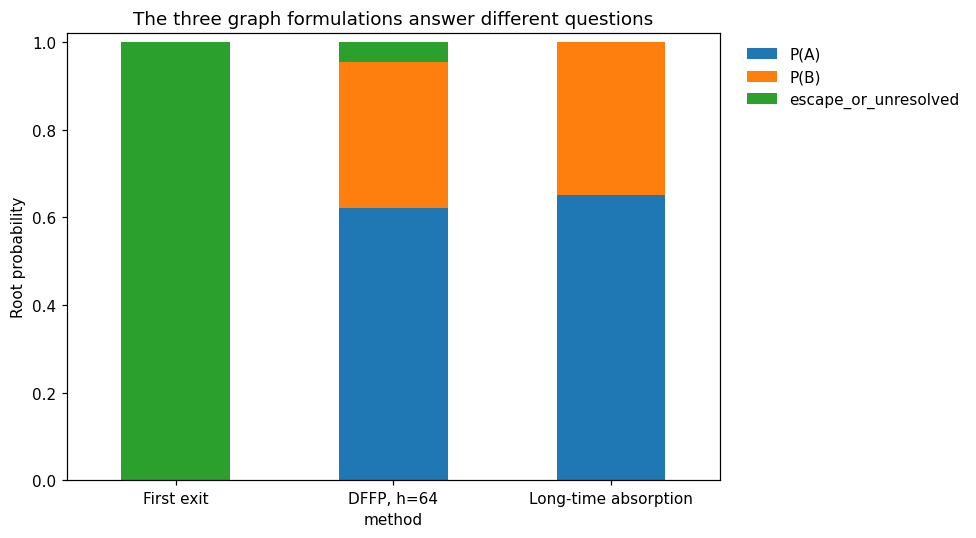

In [5]:
first_exit_transition = transition.toarray().copy()
first_exit_transition[3] = 0.0
first_exit_transition[3, 3] = 1.0
first_exit_anchors = np.zeros((5, 3), dtype=bool)
first_exit_anchors[2, 0] = True
first_exit_anchors[4, 1] = True
first_exit_anchors[3, 2] = True
first_exit = scCS.solve_discounted_outcomes(
    sparse.csr_matrix(first_exit_transition),
    first_exit_anchors,
    ("A", "B", "escape"),
    effective_horizon=64,
)

unlimited_like = scCS.solve_discounted_outcomes(
    transition,
    anchors,
    ("A", "B"),
    effective_horizon=1_000_000,
)
dffp = solutions[64]

method_table = pd.DataFrame(
    [
        {
            "method": "First exit",
            "P(A)": first_exit.probability[0, 0],
            "P(B)": first_exit.probability[0, 1],
            "escape_or_unresolved": (
                first_exit.probability[0, 2]
                + first_exit.unresolved_probability[0]
            ),
        },
        {
            "method": "DFFP, h=64",
            "P(A)": dffp.probability[0, 0],
            "P(B)": dffp.probability[0, 1],
            "escape_or_unresolved": dffp.unresolved_probability[0],
        },
        {
            "method": "Long-time absorption",
            "P(A)": unlimited_like.probability[0, 0],
            "P(B)": unlimited_like.probability[0, 1],
            "escape_or_unresolved": unlimited_like.unresolved_probability[0],
        },
    ]
).set_index("method")
display(method_table)

ax = method_table.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    ylabel="Root probability",
    title="The three graph formulations answer different questions",
)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Why a straight star cannot define the scientific velocity

A curved or loop-like source trajectory can be displayed as a straight branch,
but the display map is many-to-one and removes curvature. Native scVelo
projection onto the star is useful quality control; it is not an invertible
vector transformation.

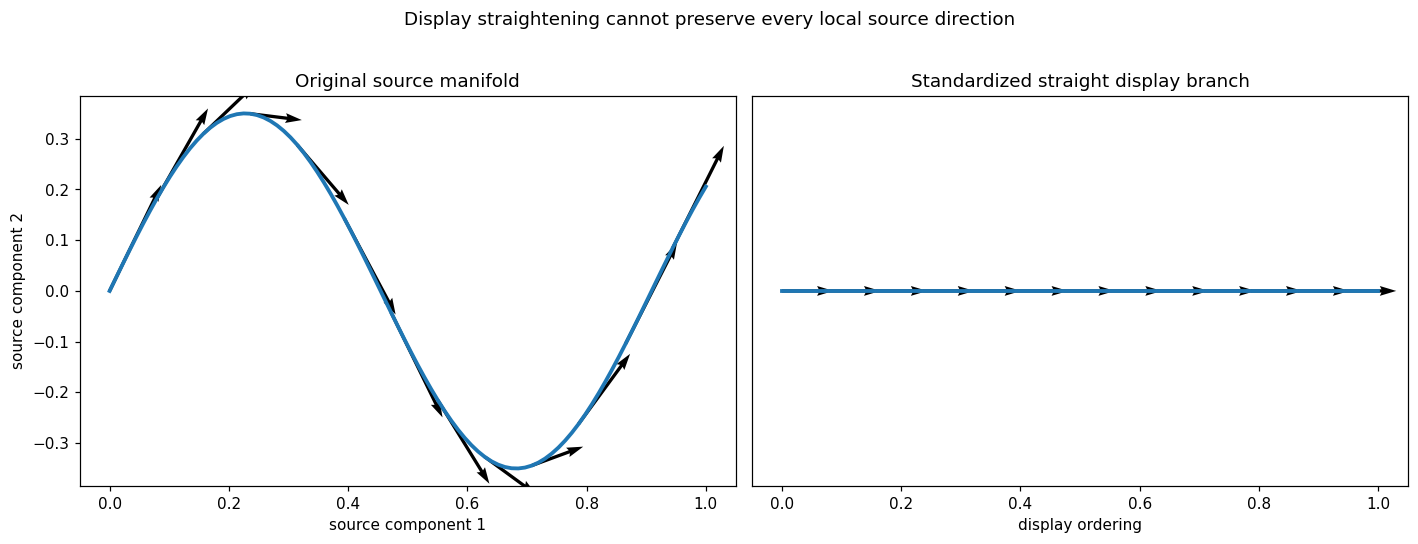

In [6]:
t = np.linspace(0, 1, 90)
source_x = t
source_y = 0.35 * np.sin(2.2 * np.pi * t)
source_dx = np.gradient(source_x)
source_dy = np.gradient(source_y)

star_x = t
star_y = np.zeros_like(t)

sample = np.arange(0, len(t), 7)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(source_x, source_y, linewidth=2.5)
axes[0].quiver(
    source_x[sample],
    source_y[sample],
    source_dx[sample],
    source_dy[sample],
    angles="xy",
    scale_units="xy",
    scale=0.13,
    width=0.005,
)
axes[0].set_title("Original source manifold")
axes[0].set_xlabel("source component 1")
axes[0].set_ylabel("source component 2")

axes[1].plot(star_x, star_y, linewidth=2.5)
axes[1].quiver(
    star_x[sample],
    star_y[sample],
    np.gradient(star_x)[sample],
    np.zeros(len(sample)),
    angles="xy",
    scale_units="xy",
    scale=0.13,
    width=0.005,
)
axes[1].set_title("Standardized straight display branch")
axes[1].set_xlabel("display ordering")
axes[1].set_yticks([])
fig.suptitle("Display straightening cannot preserve every local source direction", y=1.02)
fig.tight_layout()
plt.show()

## 8. Circular regraphing causes entropy degeneration

If neighbors are recomputed after annotated terminal cells have been placed on
one-dimensional rays, their available displacements are already constrained to
those rays. Root neighbors are similarly constrained to the incoming line.

The following schematic shows the resulting loss of informative entropy. It is
a consequence of the imposed geometry, not evidence of biologically perfect
commitment.

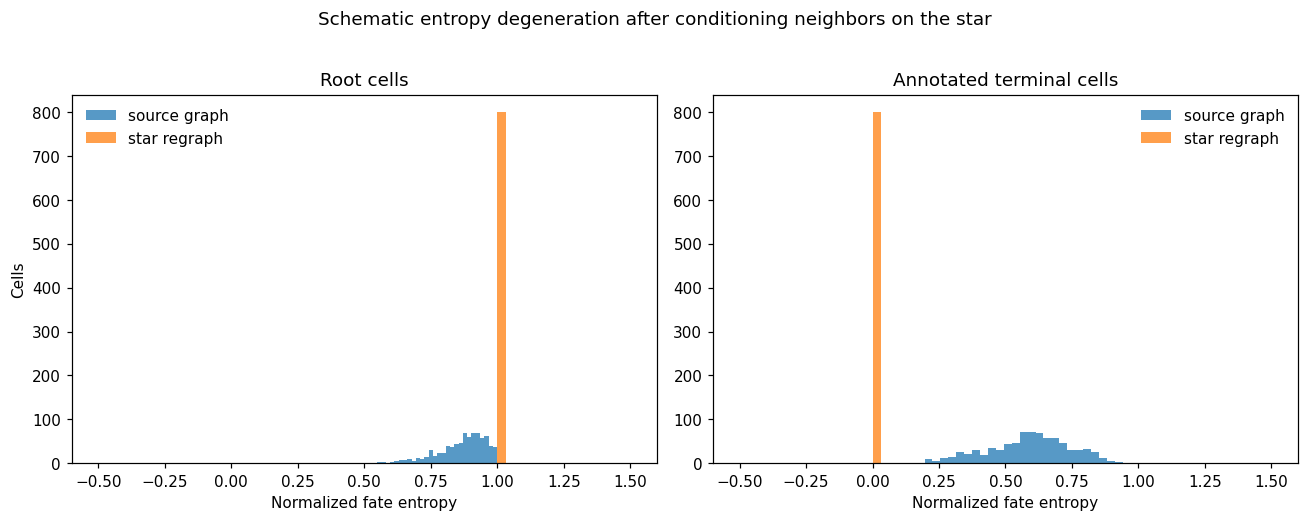

In [7]:
def normalized_entropy(probability):
    probability = np.clip(np.asarray(probability, dtype=float), 1e-15, 1.0)
    return -(probability * np.log(probability)).sum(axis=1) / np.log(probability.shape[1])

n = 800
source_root_affinity = rng.dirichlet([2.2, 2.0, 1.8, 1.6], size=n)
source_terminal_affinity = rng.dirichlet([10.0, 1.3, 1.3, 1.3], size=n)

star_regraph_root = np.full((n, 4), 0.25)
star_regraph_terminal = np.zeros((n, 4))
star_regraph_terminal[:, 0] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)
axes[0].hist(normalized_entropy(source_root_affinity), bins=30, alpha=0.75, label="source graph")
axes[0].hist(normalized_entropy(star_regraph_root), bins=30, alpha=0.75, label="star regraph")
axes[0].set_title("Root cells")
axes[0].set_xlabel("Normalized fate entropy")
axes[0].set_ylabel("Cells")
axes[0].legend(frameon=False)

axes[1].hist(
    normalized_entropy(source_terminal_affinity),
    bins=30,
    alpha=0.75,
    label="source graph",
)
axes[1].hist(
    normalized_entropy(star_regraph_terminal),
    bins=30,
    alpha=0.75,
    label="star regraph",
)
axes[1].set_title("Annotated terminal cells")
axes[1].set_xlabel("Normalized fate entropy")
axes[1].legend(frameon=False)
fig.suptitle("Schematic entropy degeneration after conditioning neighbors on the star", y=1.02)
fig.tight_layout()
plt.show()

## 9. Visual comparison of evaluated approaches

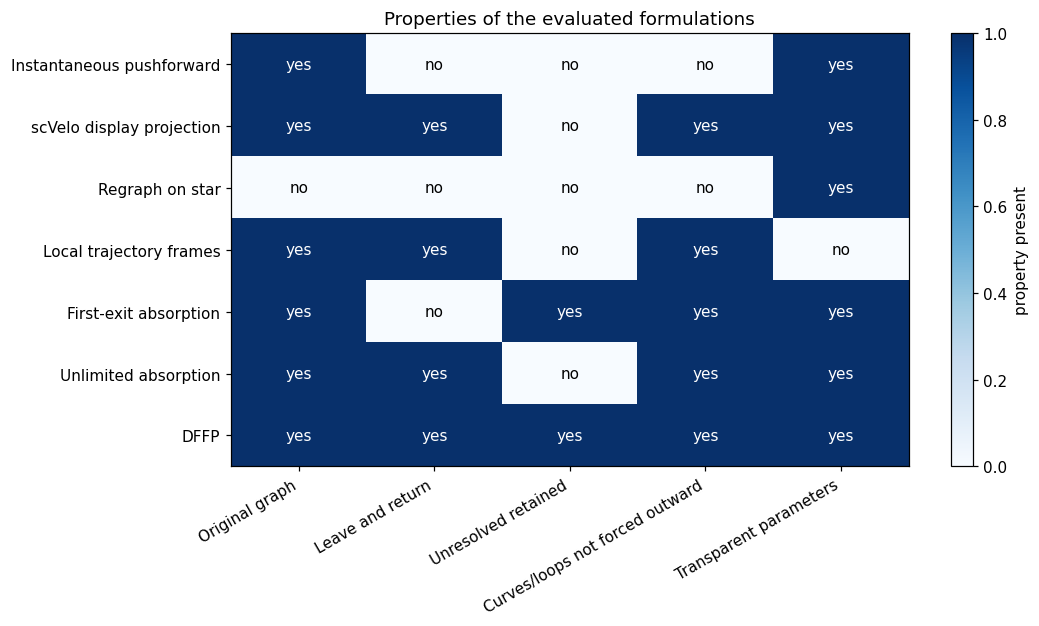

,Original graph,Leave and return,Unresolved retained,Curves/loops not forced outward,Transparent parameters
Instantaneous pushforward,1,0,0,0,1
scVelo display projection,1,1,0,1,1
Regraph on star,0,0,0,0,1
Local trajectory frames,1,1,0,1,0
First-exit absorption,1,0,1,1,1
Unlimited absorption,1,1,0,1,1
DFFP,1,1,1,1,1


In [8]:
comparison = pd.DataFrame(
    {
        "Original graph": [1, 1, 0, 1, 1, 1, 1],
        "Leave and return": [0, 1, 0, 1, 0, 1, 1],
        "Unresolved retained": [0, 0, 0, 0, 1, 0, 1],
        "Curves/loops not forced outward": [0, 1, 0, 1, 1, 1, 1],
        "Transparent parameters": [1, 1, 1, 0, 1, 1, 1],
    },
    index=[
        "Instantaneous pushforward",
        "scVelo display projection",
        "Regraph on star",
        "Local trajectory frames",
        "First-exit absorption",
        "Unlimited absorption",
        "DFFP",
    ],
)
fig, ax = plt.subplots(figsize=(10, 5.8))
image = ax.imshow(comparison.to_numpy(), vmin=0, vmax=1, cmap="Blues", aspect="auto")
ax.set_xticks(np.arange(comparison.shape[1]))
ax.set_xticklabels(comparison.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(comparison.shape[0]))
ax.set_yticklabels(comparison.index)
for row in range(comparison.shape[0]):
    for column in range(comparison.shape[1]):
        ax.text(
            column,
            row,
            "yes" if comparison.iat[row, column] else "no",
            ha="center",
            va="center",
            color="white" if comparison.iat[row, column] else "black",
        )
ax.set_title("Properties of the evaluated formulations")
fig.colorbar(image, ax=ax, label="property present")
fig.tight_layout()
plt.show()
comparison

## 10. Interpretation and reporting

DFFP was selected because it preserved the original graph, allowed temporary
excursions, retained unresolved futures, tolerated non-monotonic branches, and
stabilized before unlimited mixing.

A complete report states:

1. velocity model and source graph;
2. supervised root and fates;
3. ordering and validation;
4. effective horizon and anchor rule;
5. CFA, DFR, FFS, RC, UFP, and SOF;
6. explicit competing outcomes, if any;
7. anchor and horizon sensitivity.

The star-space velocity grid, root rose, and branch-relative profiles remain
display diagnostics rather than DFFP inputs.